In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.weightstats import ttost_paired

# Load Data

In [2]:
data = pd.read_csv('./analysis.csv')

## Preprocessing

In [3]:
# Patients or patient advocates
data['PatScoreArzt'] = data[['PatItem1Arzt', 'PatItem2Arzt', 'PatItem3Arzt','PatItem4Arzt']].sum(axis=1)
data['PatScoreKI'] = data[['PatItem1KI', 'PatItem2KI', 'PatItem3KI','PatItem4KI']].sum(axis=1)

# Expert 1: Sports scientist
data['Exp1ScoreArzt'] = data[['ExpItem1Arzt', 'ExpItem2Arzt', 'ExpItem3Arzt','ExpItem4Arzt']].sum(axis=1)
data['Exp1ScoreKI'] = data[['ExpItem1KI', 'ExpItem2KI', 'ExpItem3KI','ExpItem4KI']].sum(axis=1)

# Expert 2: Geriatric senior physician
data['Exp2ScoreArzt'] = data[['ExpItem1Arzt.1', 'ExpItem2Arzt.1', 'ExpItem3Arzt.1','ExpItem4Arzt.1']].sum(axis=1)
data['Exp2ScoreKI'] = data[['ExpItem1KI.1', 'ExpItem2KI.1', 'ExpItem3KI.1','ExpItem4KI.1']].sum(axis=1)

## Visual Inspection

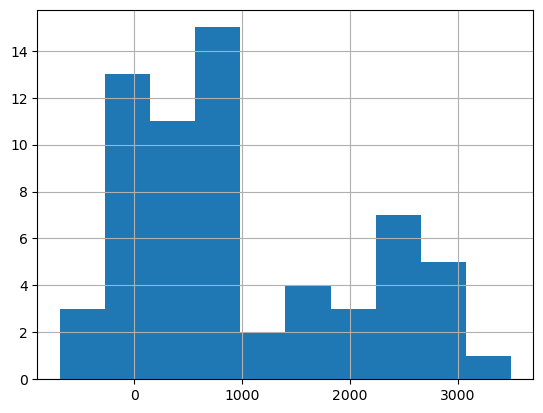

In [4]:
(data['human_translation_length'] - data['AI_translation_length']).hist();

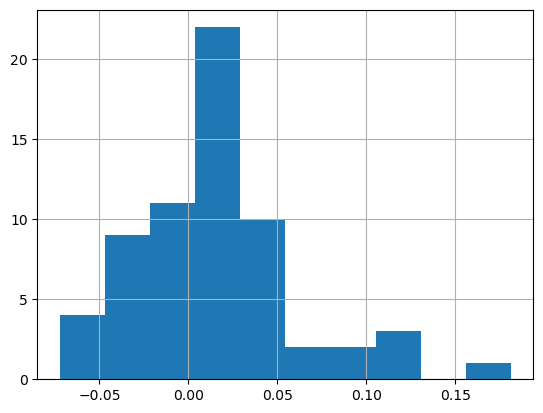

In [5]:
(data['cosine_similarity_original_vs_human'] - data['cosine_similarity_original_vs_AI']).hist();

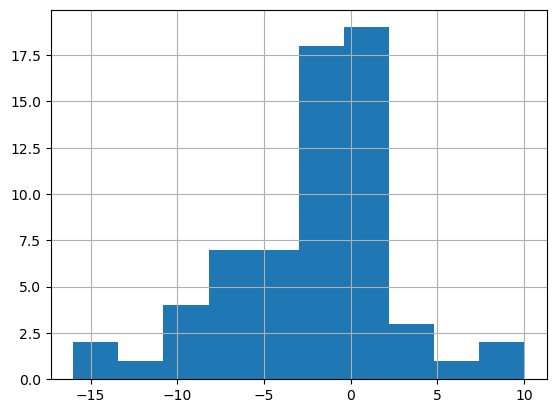

In [6]:
(data['PatScoreArzt'] - data['PatScoreKI']).hist();

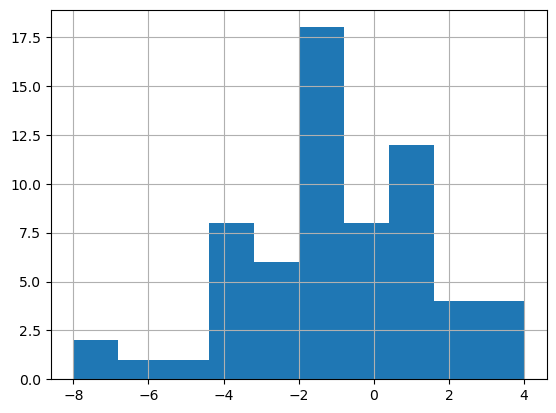

In [7]:
(data['Exp1ScoreArzt'] - data['Exp1ScoreKI']).hist();

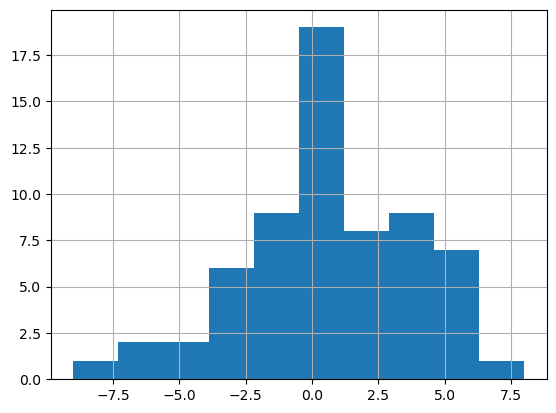

In [8]:
(data['Exp2ScoreArzt'] - data['Exp2ScoreKI']).hist();

# Statistical Analysis

## Lists

In [9]:
paired_t_tests = (
    ('Patients', 'PatScoreArzt', 'PatScoreKI'),
    ('Expert 1', 'Exp1ScoreArzt', 'Exp1ScoreKI'),
    ('Expert 2', 'Exp2ScoreArzt', 'Exp2ScoreKI')
)

wilcoxon_tests = (
    ('Patients', 'Clarity', 'PatItem1Arzt', 'PatItem1KI'),
    ('', 'Appropriateness of the content', 'PatItem2Arzt', 'PatItem2KI'),
    ('', 'Positivity of the content', 'PatItem3Arzt', 'PatItem3KI'),
    ('', 'Appropriateness of the language', 'PatItem4Arzt', 'PatItem4KI'),
    ('Expert 1', 'Clarity', 'ExpItem1Arzt', 'ExpItem1KI'),
    ('', 'Completness', 'ExpItem2Arzt', 'ExpItem2KI'),
    ('', 'Correctness', 'ExpItem3Arzt', 'ExpItem3KI'),
    ('', 'Appropriateness of the language', 'ExpItem4Arzt', 'ExpItem4KI'),
    ('Expert 2', 'Clarity', 'ExpItem1Arzt.1', 'ExpItem1KI.1'),
    ('', 'Completness', 'ExpItem2Arzt.1', 'ExpItem2KI.1'),
    ('', 'Correctness', 'ExpItem3Arzt.1', 'ExpItem3KI.1'),
    ('', 'Appropriateness of the language', 'ExpItem4Arzt.1', 'ExpItem4KI.1')
)

## Function

In [10]:
def bootstrap_ci(data1, data2, effect_fn, n_boot=1000, alpha=0.05, random_state=42):
    """
    Generic paired bootstrap CI for an effect size function.
    """
    rng = np.random.default_rng(random_state)
    n = len(data1)
    stats = []

    data1 = np.asarray(data1)
    data2 = np.asarray(data2)

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        stats.append(effect_fn(data1[idx], data2[idx]))

    lower = np.percentile(stats, 100 * (alpha / 2))
    upper = np.percentile(stats, 100 * (1 - alpha / 2))

    return lower, upper
    

def t_test_for_equivalence(array1, array2, delta, n_boot=1000):
    """
    Performs a paired t-test for equivalence (TWO-Sided Equivalence test) 
    and calculates Cohen's d with a bootstrap confidence interval.

    Args:
        array1 (array-like): First set of paired observations.
        array2 (array-like): Second set of paired observations.
        delta (float): The equivalence margin.
        n_boot (int): Number of bootstrap iterations for the confidence interval.

    Returns:
        dict: Results containing the test type, means, standard deviations, 
              Cohen's d, its CI, the p-value, and detailed results for the 
              lower and upper boundaries.
    """
    pvalue, (t1, p1, df1), (t2, p2, df2) = ttost_paired(
        array1, array2,
        low=-delta,
        upp=delta
    )

    diff = np.asarray(array1) - np.asarray(array2)
    cohen_d = np.mean(diff) / np.std(diff, ddof=1)

    d_ci = bootstrap_ci(
        array1, array2,
        effect_fn=lambda a, b: np.mean(a - b) / np.std(a - b, ddof=1),
        n_boot=n_boot
    )

    return {
        "test": "paired_t_test_for_equivalence",
        "mean_array1": np.mean(array1),
        "mean_array2": np.mean(array2),
        "std_array1": np.std(array1, ddof=1),
        "std_array2": np.std(array2, ddof=1),
        "cohen_d": cohen_d,
        "cohen_d_ci": d_ci,
        "p_value": pvalue,
        "lower_test": (t1, p1, df1),
        "upper_test": (t2, p2, df2),
    }
    

def paired_t_test(array1, array2, n_boot=1000):
    """
    Performs a paired t-test to compare the means of two related groups 
    and calculates Cohen's d with a bootstrap confidence interval.

    Args:
        array1 (array-like): First set of paired observations.
        array2 (array-like): Second set of paired observations.
        n_boot (int): Number of bootstrap iterations for the confidence interval.

    Returns:
        dict: Results containing the test type, means, standard deviations, 
              Cohen's d, its CI, the t-statistic, and the p-value.
    """
    stat, p = stats.ttest_rel(array1, array2)

    diff = np.asarray(array1) - np.asarray(array2)
    cohen_d = np.mean(diff) / np.std(diff, ddof=1)

    d_ci = bootstrap_ci(
        array1, array2,
        effect_fn=lambda a, b: np.mean(a - b) / np.std(a - b, ddof=1),
        n_boot=n_boot
    )

    return {
        "test": "paired_t_test",
        "mean_array1": np.mean(array1),
        "mean_array2": np.mean(array2),
        "std_array1": np.std(array1, ddof=1),
        "std_array2": np.std(array2, ddof=1),
        "cohen_d": cohen_d,
        "cohen_d_ci": d_ci,
        "statistic": stat,
        "p_value": p
    }

def wilcoxon_test(array1, array2, n_boot=1000):
    """
    Performs a Wilcoxon signed-rank test for paired samples and 
    calculates the rank-biserial correlation with a bootstrap confidence interval.

    Args:
        array1 (array-like): First set of paired observations.
        array2 (array-like): Second set of paired observations.
        n_boot (int): Number of bootstrap iterations for the confidence interval.

    Returns:
        dict: Results containing the test type, medians, Interquartile Ranges (IQR), 
              rank-biserial correlation, its CI, the test statistic, and the p-value.
    """
    stat, p = stats.wilcoxon(
        array1,
        array2,
        zero_method='wilcox',
        mode='auto'
    )

    diff = np.asarray(array1) - np.asarray(array2)
    diff_nz = diff[diff != 0]

    if len(diff_nz) == 0:
        rank_biserial = np.nan
        r_ci = (np.nan, np.nan)
    else:
        ranks = stats.rankdata(np.abs(diff_nz))
        W_pos = np.sum(ranks[diff_nz > 0])
        W_neg = np.sum(ranks[diff_nz < 0])
        rank_biserial = (W_pos - W_neg) / (W_pos + W_neg)

        # bootstrap CI
        r_ci = bootstrap_ci(
            array1, array2,
            effect_fn=lambda a, b: (
                lambda d: (
                    np.sum(stats.rankdata(np.abs(d[d != 0]))[d[d != 0] > 0]) -
                    np.sum(stats.rankdata(np.abs(d[d != 0]))[d[d != 0] < 0])
                ) / (
                    np.sum(stats.rankdata(np.abs(d[d != 0]))[d[d != 0] > 0]) +
                    np.sum(stats.rankdata(np.abs(d[d != 0]))[d[d != 0] < 0])
                ) if len(d[d != 0]) > 0 else np.nan
            )(a - b),
            n_boot=n_boot
        )

    return {
        "test": "wilcoxon_signed_rank",
        "median_array1": np.median(array1),
        "median_array2": np.median(array2),
        "iqr_array1": tuple(np.percentile(array1, [25, 75])),
        "iqr_array2": tuple(np.percentile(array2, [25, 75])),
        "rank_biserial": rank_biserial,
        "rank_biserial_ci": r_ci,
        "statistic": stat,
        "p_value": p
    }


def spearman_rho(x, y, n_boot=1000, alpha=0.05, random_state=42):
    """
    Calculates the Spearman rank correlation coefficient, its p-value, 
    and a bootstrap confidence interval.

    Args:
        x (array-like): First variable.
        y (array-like): Second variable.
        n_boot (int): Number of bootstrap iterations.
        alpha (float): Significance level for the confidence interval.
        seed (int): Random seed for reproducibility.

    Returns:
        dict: Results containing the correlation coefficient (rho), 
              the p-value, and the lower and upper bounds of the CI.
    """
    rng = np.random.default_rng(random_state)
    n = len(x)
    boot_corrs = []

    x = np.asarray(x)
    y = np.asarray(y)

    # Calculate original Spearman rho and p-value
    rho, p_value = stats.spearmanr(x, y)

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        boot_corrs.append(stats.spearmanr(x[idx], y[idx]).correlation)

    lower = np.percentile(boot_corrs, 100 * (alpha / 2))
    upper = np.percentile(boot_corrs, 100 * (1 - alpha / 2))

    return {
        "test": "spearman_correlation",
        "rho": rho,
        "p_value": p_value,
        "rho_ci": (lower, upper)
    }

## Analysis

### Semantic Similarity

In [11]:
# Cosine Similarity Variables
human = 'cosine_similarity_original_vs_human'
ai = 'cosine_similarity_original_vs_AI'

# Inter-simplifier reference (effect size anchor)
human1 = data.loc[data['Experte'] == 'Thomas', human]
human2 = data.loc[data['Experte'] == 'Filippo', human]
delta = abs(human1.mean() - human2.mean())

# Cohen's d (human vs human)
ref_diff = np.asarray(human2) - np.asarray(human1)
reference_cohen_d = np.mean(ref_diff) / np.std(ref_diff, ddof=1)

ref_cohen_ci = bootstrap_ci(
    human1,
    human2,
    effect_fn=lambda a, b: np.mean(b - a) / np.std(b - a, ddof=1),
    n_boot=1000
)

# Equivalence test (AI vs human)
results = t_test_for_equivalence(
    data[human],
    data[ai],
    delta
)

# Print results
print(f"{'Mean human:':<30} {results['mean_array1']:>10.3f} ± {results['std_array1']:.3f}")
print(f"{'Mean AI:':<30} {results['mean_array2']:>10.3f} ± {results['std_array2']:.3f}")
print(f"{'Delta (equivalence margin):':<30} {delta:>10.3f}")
print(f"{"Cohen's d (AI vs human):":<30} {results['cohen_d']:>10.3f}")
print(f"{"Cohen's d CI (AI vs human):":<30}      [{results['cohen_d_ci'][0]:.3f}, {results['cohen_d_ci'][1]:.3f}]")
print(f"{"Cohen's d (human vs human):":<30} {reference_cohen_d:>10.3f}")
print(f"{"Cohen's d CI (human vs human):":<30}      [{ref_cohen_ci[0]:.3f}, {ref_cohen_ci[1]:.3f}]")
print(f"{'TOST p-value:':<30} {results['p_value']:>10.3f}")

Mean human:                         0.767 ± 0.041
Mean AI:                            0.749 ± 0.042
Delta (equivalence margin):         0.030
Cohen's d (AI vs human):            0.379
Cohen's d CI (AI vs human):         [0.163, 0.605]
Cohen's d (human vs human):         0.482
Cohen's d CI (human vs human):      [0.153, 0.910]
TOST p-value:                       0.018


### Main results

In [12]:
main_results = pd.DataFrame(
    columns=[
        'Rater',
        'Mean ± SD (human)',
        'Mean ± SD (AI)',
        "Cohen's d",
        "95% CI",
        'p-value'
    ]
)

for rater, human, ai in paired_t_tests:
    results = paired_t_test(data[human], data[ai])

    mean_sd_human = f"{results['mean_array1']:.3f} ± {results['std_array1']:.3f}"
    mean_sd_ai = f"{results['mean_array2']:.3f} ± {results['std_array2']:.3f}"
    p_value = f"{results['p_value']:.3f}"

    ci = results.get('cohen_d_ci', (np.nan, np.nan))
    ci_str = f"[{ci[0]:.3f}, {ci[1]:.3f}]"

    row = {
        'Rater': rater,
        'Mean ± SD (human)': mean_sd_human,
        'Mean ± SD (AI)': mean_sd_ai,
        "Cohen's d": f"{results['cohen_d']:.3f}",
        "95% CI": ci_str,
        'p-value': p_value
    }

    main_results = pd.concat(
        [main_results, pd.DataFrame([row])],
        ignore_index=True
    )

main_results.to_csv('./main_results.csv', index=False)
main_results

,Rater,Mean ± SD (human),Mean ± SD (AI),Cohen's d,95% CI,p-value
0,Patients,14.953 ± 4.274,17.266 ± 3.123,-0.478,"[-0.739, -0.243]",0.000
1,Expert 1,16.766 ± 1.925,17.891 ± 1.416,-0.448,"[-0.705, -0.216]",0.001
2,Expert 2,14.516 ± 2.475,13.922 ± 2.339,0.185,"[-0.063, 0.473]",0.145


### Individual items

In [13]:
individual_items = pd.DataFrame(
    columns=[
        'Rater',
        'Item',
        'Median (IQR) human',
        'Median (IQR) AI',
        'Rank-biserial r',
        '95% CI',
        'p-value'
    ]
)

for rater, item, human, ai in wilcoxon_tests:
    results = wilcoxon_test(data[human], data[ai])

    med1 = int(results['median_array1'])
    iqr1_low, iqr1_high = [float(x) for x in results['iqr_array1']]
    median_iqr_human = f"{med1} ({iqr1_low}, {iqr1_high})"

    med2 = int(results['median_array2'])
    iqr2_low, iqr2_high = [float(x) for x in results['iqr_array2']]
    median_iqr_ai = f"{med2} ({iqr2_low}, {iqr2_high})"

    p_value = f"{results['p_value']:.3f}"

    ci = results.get('rank_biserial_ci', (np.nan, np.nan))
    ci_str = f"[{ci[0]:.3f}, {ci[1]:.3f}]"

    row = {
        'Rater': rater,
        'Item': item,
        'Median (IQR) human': median_iqr_human,
        'Median (IQR) AI': median_iqr_ai,
        'Rank-biserial r': f"{results['rank_biserial']:.3f}",
        '95% CI': ci_str,
        'p-value': p_value
    }

    individual_items = pd.concat(
        [individual_items, pd.DataFrame([row])],
        ignore_index=True
    )

individual_items.to_csv('./individual_items.csv', index=False)
individual_items

,Rater,Item,Median (IQR) human,Median (IQR) AI,Rank-biserial r,95% CI,p-value
0,Patients,Clarity,"4 (3.0, 5.0)","5 (4.0, 5.0)",-0.642,"[-0.891, -0.352]",0.001
1,,Appropriateness of the content,"4 (3.0, 5.0)","5 (4.0, 5.0)",-0.663,"[-0.880, -0.389]",0.001
2,,Positivity of the content,"4 (3.0, 5.0)","5 (4.0, 5.0)",-0.474,"[-0.760, -0.157]",0.011
3,,Appropriateness of the language,"4 (3.0, 5.0)","5 (4.0, 5.0)",-0.582,"[-0.820, -0.271]",0.001
4,Expert 1,Clarity,"4 (4.0, 5.0)","5 (5.0, 5.0)",-0.899,"[-1.000, -0.741]",0.000
5,,Completness,"5 (4.0, 5.0)","4 (4.0, 5.0)",0.527,"[0.248, 0.777]",0.001
6,,Correctness,"4 (4.0, 4.0)","4 (4.0, 5.0)",-0.440,"[-0.737, -0.131]",0.010
7,,Appropriateness of the language,"4 (4.0, 5.0)","5 (4.0, 5.0)",-0.821,"[-0.946, -0.636]",0.000
8,Expert 2,Clarity,"4 (3.0, 4.0)","4 (3.75, 4.0)",-0.333,"[-0.669, 0.014]",0.060
9,,Completness,"4 (3.0, 4.0)","3 (2.0, 4.0)",0.712,"[0.488, 0.890]",0.000


## Text Length

In [14]:
human = 'human_translation_length'
ai = 'AI_translation_length'

results = paired_t_test(data[human], data[ai])

# Print results
print(f"{'Mean ± SD humans:':<25} {results['mean_array1']:.3f} ± {results['std_array1']:.3f}")
print(f"{'Mean ± SD AI:':<25} {results['mean_array2']:.3f} ± {results['std_array2']:.3f}")
print(f"{'Cohen dz:':<25} {results['cohen_d']:.3f}")
print(f"{'Cohen dz CI:':<25} [{results['cohen_d_ci'][0]:.3f}, {results['cohen_d_ci'][1]:.3f}]")
print(f"{'p-value:':<25} {results['p_value']:.3f}")

Mean ± SD humans:         2509.625 ± 1078.645
Mean ± SD AI:             1522.797 ± 163.247
Cohen dz:                 0.933
Cohen dz CI:              [0.752, 1.145]
p-value:                  0.000


### Rater 1

In [15]:
x = np.concatenate((data[ai].values, data[human].values))
y = np.concatenate((data['ExpItem2KI'].values, data['ExpItem2Arzt'].values))

results = spearman_rho(x, y)

# Print results
print(f"{'Spearman correlation:':<25} {results['rho']:>10.3f}")
print(f"{'95% CI:':<25}      [{results['rho_ci'][0]:.3f}, {results['rho_ci'][1]:.3f}]")
print(f"{'p-value:':<25} {results['p_value']:>10.3f}")

Spearman correlation:          0.291
95% CI:                        [0.119, 0.439]
p-value:                       0.001


### Rater 2

In [16]:
x = np.concatenate((data[ai].values, data[human].values))
y = np.concatenate((data['ExpItem2KI.1'].values, data['ExpItem2Arzt.1'].values))

results = spearman_rho(x, y)

# Print results
print(f"{'Spearman correlation:':<25} {results['rho']:>10.3f}")
print(f"{'95% CI:':<25}      [{results['rho_ci'][0]:.3f}, {results['rho_ci'][1]:.3f}]")
print(f"{'p-value:':<25} {results['p_value']:>10.3f}")

Spearman correlation:          0.246
95% CI:                        [0.078, 0.396]
p-value:                       0.005


# Export Data

In [17]:
data.to_csv('./GISelA.csv', index=False)
data.to_excel('./GISelA.xlsx', index=False)